In [1]:
import os

import numpy as np
import optuna
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.preprocessing import MinMaxScaler, StandardScaler, FunctionTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

scaler = MinMaxScaler()

/home/jakob/.pyenv/versions/3.13.12/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def train_one_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for images_loaded, prices_loaded, tokens_loaded, ratings_loaded in train_loader:
        images_temp = images_loaded.float().to(device)
        prices_temp = prices_loaded.float().unsqueeze(1).to(device)
        tokens_temp = tokens_loaded.float().to(device)
        ratings_temp = ratings_loaded.float().unsqueeze(1).to(device)

        preds = model(images_temp, prices_temp, tokens_temp)
        loss = criterion(preds, ratings_temp)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for images_loaded, prices_loaded, tokens_loaded, ratings_loaded in loader:
            images_temp = images_loaded.float().to(device)
            prices_temp = prices_loaded.float().unsqueeze(1).to(device)
            tokens_temp = tokens_loaded.float().to(device)
            ratings_temp = ratings_loaded.float().unsqueeze(1).to(device)

            preds = model(images_temp, prices_temp, tokens_temp)
            loss = criterion(preds, ratings_temp)
            total_loss += loss.item()

    return total_loss / len(loader)


class ImagePriceRatingDataset(Dataset):
    def __init__(self, ratings, images, prices, tokens):
        if not (len(ratings) == len(images) == len(prices) == len(tokens)):
            raise ValueError("ratings, images, prices and tokens must have equal length")
        self.ratings = ratings
        self.images = images
        self.prices = prices
        self.tokens = tokens

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.images[idx], self.prices[idx], self.tokens[idx], self.ratings[idx]
    


In [3]:
# Find unique entries
unique_path = r"../data/grand_scraper_folder/unique_scrandle_cases_FULL.csv"
unique_dataframe = pd.read_csv(unique_path)
unique_entries = [unique_dataframe["occurrences"][i].split("|")[0].split(" ")[0] + ".webp" for i in range(len(unique_dataframe["occurrences"]))]

In [4]:
#Next, we´ll get the low-res photos imported(doesnt take long. for my computer: 7.5s)

#Creating a list for the photos with the corresponding dates and image names as well(crude way of being able to see which are outliers.
#Needs to be done better, really. If someone has the time, feel free to find a better way of doing things)
images_raw = []

#Next, a list for the metadata i want(for now, at least. there´s certainly going to be a better way of doing this later):
metadata_raw = []
tokendata_raw = []

#Folder with folders of images:
base_folder = r"../data/scran_sized_low_res_data"
#Meta data folders(yes, a bit inefficient. CHANGE LATER):
meta_folder = r"../data/grand_scraper_folder/scrandle_data"
current_folder = None


#Looping over all dates in the listed directory/folder:
for entry in sorted(unique_entries):
    date, image_placement = entry.split(":")
    
    #Finding a new date folder to check
    date_path = os.path.join(base_folder, date)
    meta_date_path = os.path.join(meta_folder, date)
    #Checking if the date path exists
    if not os.path.isdir(date_path):
        continue

    #print(f"Processing {entry}")
    
    #Reading entry image:
    image_path = os.path.join(date_path, image_placement)
    images_raw.append({
                    "date": date,
                    "image_name": image_placement,
                    "RGB": plt.imread(image_path, format="webp"),
                })

    if current_folder != date:
        current_folder = date
        meta_path = os.path.join(meta_folder, date, "meta.csv")
        meta_intermediate = pd.read_csv(meta_path)
        meta_tokens = pd.read_csv(meta_path,sep=",").fillna("")
        
        
    entry_row = meta_intermediate.loc[meta_intermediate["image_name"] == image_placement]
    metadata_raw.append({
                "price": entry_row["price"],
                "rating": entry_row["rating"],
                "year": entry_row["year"],
                "date": entry_row["date"],
                "image_name": entry_row["image_name"],
                "title": entry_row["title"],
                "subtitle": entry_row["subtitle"],
                "club": entry_row["club"],
                "country": entry_row["country"],
            })
    tokendata_raw.append(f"{entry_row["title"].iloc[0]} {entry_row["subtitle"].iloc[0]} {entry_row["country"].iloc[0]} {entry_row["club"].iloc[0]}")

In [5]:
# build original arrays
ratings = []
for i in range(len(metadata_raw)):
    ratings += metadata_raw[i]["rating"].to_list()
ratings = np.array(ratings, dtype=float) / 100

prices = []
for i in range(len(metadata_raw)):
    prices += metadata_raw[i]["price"].to_list()
prices = np.array(prices, dtype=float)
prices[np.isnan(prices)] = 0.0

vectorizer = CountVectorizer()
tokens_csr = vectorizer.fit_transform(tokendata_raw)
tokens = tokens_csr.toarray().astype(np.float32) / 3.0

images_np = np.stack([img["RGB"] for img in images_raw]).astype(np.float32)  # (N, H, W, C)

# split original indices first to avoid mirror leakage
idx = np.arange(len(images_np))
train_idx, val_idx = train_test_split(idx, test_size=0.2, random_state=42, shuffle=True)

def make_split(indices, scaler=None, fit_scaler=False):
    imgs = images_np[indices]  # (M, H, W, C)

    imgs_lr = np.flip(imgs, axis=2).copy()          # mirror left-right
    imgs_ud = np.flip(imgs, axis=1).copy()          # flip upside down
    imgs_both = np.flip(imgs, axis=(1, 2)).copy()   # flip both directions

    imgs_all = np.concatenate([imgs, imgs_lr, imgs_ud, imgs_both], axis=0)
    imgs_tensor = torch.from_numpy(imgs_all / 255.0).permute(0, 3, 1, 2).float()

    prices_sel = prices[indices].astype(float)
    if fit_scaler:
        scaler_local = MinMaxScaler()
        prices_scaled = scaler_local.fit_transform(prices_sel.reshape(-1, 1)).ravel()
        scaler = scaler_local
    else:
        prices_scaled = scaler.transform(prices_sel.reshape(-1, 1)).ravel()
    prices_all = np.concatenate([prices_scaled, prices_scaled, prices_scaled, prices_scaled], axis=0)
    prices_tensor = torch.tensor(prices_all, dtype=torch.float32)

    tokens_sel = tokens[indices]
    tokens_all = np.concatenate([tokens_sel, tokens_sel, tokens_sel, tokens_sel], axis=0)
    tokens_tensor = torch.tensor(tokens_all, dtype=torch.float32)

    ratings_sel = ratings[indices].astype(float)
    ratings_all = np.concatenate([ratings_sel, ratings_sel, ratings_sel, ratings_sel], axis=0)
    ratings_tensor = torch.tensor(ratings_all, dtype=torch.float32)

    return imgs_tensor, prices_tensor, tokens_tensor, ratings_tensor, scaler

# build train (fit scaler) and validation (use train scaler) splits
train_images, train_prices, train_tokens, train_ratings, scaler_train = make_split(train_idx, fit_scaler=True)
val_images, val_prices, val_tokens, val_ratings, _ = make_split(val_idx, scaler=scaler_train, fit_scaler=False)

# create datasets and loaders (mirrors are contained within each split)
train_dataset = ImagePriceRatingDataset(train_ratings, train_images, train_prices, train_tokens)
val_dataset = ImagePriceRatingDataset(val_ratings, val_images, val_prices, val_tokens)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


In [6]:
n_tokens = tokens.shape[1]
class ImagePriceModel(nn.Module):
    def __init__(self, token_dim=n_tokens):
        super().__init__()
        weights = ResNet50_Weights.IMAGENET1K_V2
        image_branch = resnet50(weights=weights)
        self.image_branch = nn.Sequential(*list(image_branch.children())[:-1])  # 2048 features

        self.price_branch = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
        )

        self.token_branch = nn.Sequential(
            nn.Linear(token_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 128),
            nn.ReLU(),
        )

        joint_dim = 2048 + 16 + 128
        self.head = nn.Sequential(
            nn.Linear(joint_dim, 1024),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, image, price, token):
        img_feat = self.image_branch(image).flatten(1)   
        price_feat = self.price_branch(price)                
        token_feat = self.token_branch(token)                
        x = torch.cat([img_feat, price_feat, token_feat], dim=1)
        return self.head(x)


device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using Device: {device}")

model = ImagePriceModel().to(device)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


# training loop (replace existing loop with this)
for epoch in range(10):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = evaluate_loss(model, test_loader, criterion, device)
    print(f"epoch {epoch+1}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

Using Device: cuda
epoch 1: train_loss=0.1312 | val_loss=0.1242
epoch 2: train_loss=0.0776 | val_loss=0.1198
epoch 3: train_loss=0.0623 | val_loss=0.1170
epoch 4: train_loss=0.0542 | val_loss=0.1152
epoch 5: train_loss=0.0496 | val_loss=0.1174
epoch 6: train_loss=0.0470 | val_loss=0.1188
epoch 7: train_loss=0.0450 | val_loss=0.1197
epoch 8: train_loss=0.0426 | val_loss=0.1139
epoch 9: train_loss=0.0415 | val_loss=0.1138
epoch 10: train_loss=0.0403 | val_loss=0.1161


In [7]:
epochs = [10, 5, 2]
learning_rates = [1e-4, 1e-5, 5e-7]


for i in range(len(epochs)):
    print(f"Initiating Fine Grid Level {i+1} |  Epochs: {epochs[i]} | Learning Rate: {learning_rates[i]}")
    optimizer_fine = torch.optim.Adam(model.parameters(), lr=learning_rates[i])

    for epoch in range(epochs[i]):
        train_loss = train_one_epoch(model, train_loader, optimizer_fine, criterion, device)
        val_loss = evaluate_loss(model, test_loader, criterion, device)
        print(f"epoch {epoch+1}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")



Initiating Fine Grid Level 1 |  Epochs: 10 | Learning Rate: 0.0001
epoch 1: train_loss=0.0352 | val_loss=0.1138
epoch 2: train_loss=0.0327 | val_loss=0.1120
epoch 3: train_loss=0.0317 | val_loss=0.1129
epoch 4: train_loss=0.0305 | val_loss=0.1115
epoch 5: train_loss=0.0300 | val_loss=0.1126
epoch 6: train_loss=0.0298 | val_loss=0.1117
epoch 7: train_loss=0.0294 | val_loss=0.1121
epoch 8: train_loss=0.0286 | val_loss=0.1117
epoch 9: train_loss=0.0285 | val_loss=0.1118
epoch 10: train_loss=0.0282 | val_loss=0.1116
Initiating Fine Grid Level 2 |  Epochs: 5 | Learning Rate: 1e-05
epoch 1: train_loss=0.0274 | val_loss=0.1120
epoch 2: train_loss=0.0270 | val_loss=0.1116
epoch 3: train_loss=0.0273 | val_loss=0.1120
epoch 4: train_loss=0.0270 | val_loss=0.1114
epoch 5: train_loss=0.0269 | val_loss=0.1121
Initiating Fine Grid Level 3 |  Epochs: 2 | Learning Rate: 5e-07
epoch 1: train_loss=0.0267 | val_loss=0.1114
epoch 2: train_loss=0.0267 | val_loss=0.1116


In [8]:
torch.save(model.state_dict(), "model_weights")

In [9]:
model.eval()

preds_train = []
trues_train = []

with torch.no_grad():
    for images_loaded, prices_loaded, tokens_loaded, ratings_loaded in train_loader:
        images_loaded = images_loaded.to(device)
        prices_loaded = prices_loaded.float().unsqueeze(1).to(device)
        tokens_loaded = tokens_loaded.to(device)
        outputs = model(images_loaded, prices_loaded, tokens_loaded).squeeze(1)

        preds_train.append(outputs.cpu())
        trues_train.append(ratings_loaded.cpu())

preds_train = torch.cat(preds_train).numpy()
trues_train = torch.cat(trues_train).numpy()


preds_test = []
trues_test = []

with torch.no_grad():
    for images_loaded, prices_loaded, tokens_loaded, ratings_loaded in test_loader:
        images_loaded = images_loaded.to(device)
        prices_loaded = prices_loaded.float().unsqueeze(1).to(device)
        tokens_loaded = tokens_loaded.to(device)
        outputs = model(images_loaded, prices_loaded, tokens_loaded).squeeze(1)

        preds_test.append(outputs.cpu())
        trues_test.append(ratings_loaded.cpu())

preds_test = torch.cat(preds_test).numpy()
trues_test = torch.cat(trues_test).numpy()


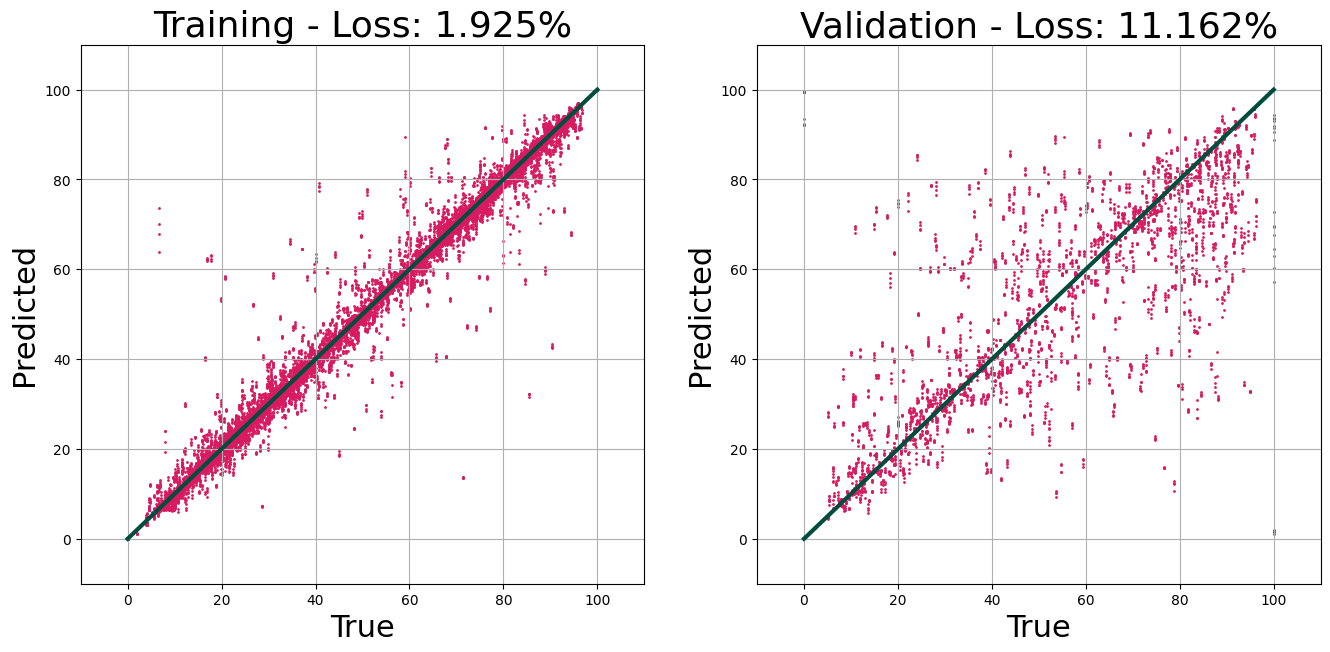

In [10]:
mask = trues_train != 0.0
loss_train = np.mean(np.abs(preds_train - trues_train))

fig, ax = plt.subplots(1,2, figsize=(16,7))
ax[0].plot([0, 100], [0, 100], color="#004D40", linewidth=3)
ax[0].scatter(100 * trues_train, 100 * preds_train, color="#D81B60", s=1)
ax[0].set_xlim(-10,110)
ax[0].set_ylim(-10,110)
ax[0].set_xlabel("True", fontsize=22)
ax[0].set_ylabel("Predicted", fontsize=22)
ax[0].set_title(f"Training - Loss: {loss_train*100:.3f}%", fontsize=26)
ax[0].grid()

mask = trues_test != 0.0
loss_test = np.mean(np.abs(preds_test - trues_test))

ax[1].plot([0, 100], [0, 100], color="#004D40", linewidth=3)
ax[1].scatter(100 * trues_test, 100 * preds_test, color="#D81B60", s=1)
ax[1].set_xlim(-10,110)
ax[1].set_ylim(-10,110)
ax[1].set_xlabel("True", fontsize=22)
ax[1].set_ylabel("Predicted", fontsize=22)
ax[1].set_title(f"Validation - Loss: {loss_test*100:.3f}%", fontsize=26)
ax[1].grid()
plt.show()

# Optuna

In [11]:
def objective(trial):
    # Select Device for compute
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Optimization Parameters
    batch_size = trial.suggest_int("batch_size", 16, 128, step=16)
    lr = trial.suggest_float("lr", 1e-5, 3e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)

    token_hidden = trial.suggest_categorical("token_hidden", [64, 128, 256, 512, 1024, 2048, 4096])
    head_hidden = trial.suggest_categorical("head_hidden", [128, 256, 512, 1024])

    # Split data set
    dataset = ImagePriceRatingDataset(ratings, images, prices, tokens)
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size

    train_dataset, val_dataset = random_split(
        dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42),
    )
    direction="minimize",
    sampler=sampler,
)
    # Create Dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Create Model
    class ImagePriceModel(nn.Module):
        def __init__(self, token_dim=n_tokens):
            super().__init__()
            weights = ResNet50_Weights.IMAGENET1K_V2
            image_branch = resnet50(weights=weights)
            self.image_branch = nn.Sequential(*list(image_branch.children())[:-1])

            self.price_branch = nn.Sequential(
                nn.Linear(1, 16),
                nn.ReLU(),
                nn.Linear(16, 16),
                nn.ReLU(),
            )

            self.token_branch = nn.Sequential(
                nn.Linear(token_dim, token_hidden),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.Linear(token_hidden, token_hidden),
                nn.ReLU(),    direction="minimize",
    sampler=sampler,
)
            )

            joint_dim = 2048 + 16 + token_hidden
            self.head = nn.Sequential(
                nn.Linear(joint_dim, head_hidden),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.Linear(head_hidden, head_hidden // 2),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.Linear(head_hidden // 2, 1),
                nn.Sigmoid(),
            )

        def forward(self, image, price, token):
            img_feat = self.image_branch(image).flatten(1)
            price_feat = self.price_branch(price)
            token_feat = self.token_branch(token)
            x = torch.cat([img_feat, price_feat, token_feat], dim=1)
            return self.head(x)

    # Instaniate model and criterion and optimizer
    model = ImagePriceModel().to(device)
    criterion = nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_loss = float("inf")
    patience = 5
    bad_epochs = 0
    
    for epoch in range(20):
        model.train()
        train_loss = 0.0

        for images_loaded, prices_loaded, tokens_loaded, ratings_loaded in train_loader:
            images_loaded = images_loaded.float().to(device)
            prices_loaded = prices_loaded.float().unsqueeze(1).to(device)
            tokens_loaded = tokens_loaded.float().to(device)
            ratings_loaded = ratings_loaded.float().unsqueeze(1).to(device)

            preds = model(images_loaded, prices_loaded, tokens_loaded)
            loss = criterion(preds, ratings_loaded)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images_loaded, prices_loaded, tokens_loaded, ratings_loaded in val_loader:
                images_loaded = images_loaded.float().to(device)
                prices_loaded = prices_loaded.float().unsqueeze(1).to(device)
                tokens_loaded = tokens_loaded.float().to(device)
                ratings_loaded = ratings_loaded.float().unsqueeze(1).to(device)

                preds = model(images_loaded, prices_loaded, tokens_loaded)
                loss = criterion(preds, ratings_loaded)
                val_loss += loss.item()

        val_loss /= len(val_loader)

        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            break

    return best_val_loss


sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(
    study_name="Ratings Identifier",
    direction="minimize",
    sampler=sampler,
)
study.optimize(objective, n_trials=150, show_progress_bar=True, n_jobs=1)

SyntaxError: unmatched ')' (2173082480.py, line 26)